In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

In [3]:
df = pd.read_csv("Dataset.csv", encoding="latin1")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (9551, 21)


,ï»¿Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [4]:
df[['Restaurant Name','City','Locality','Latitude','Longitude',
    'Aggregate rating','Price range','Cuisines']].head()

,Restaurant Name,City,Locality,Latitude,Longitude,Aggregate rating,Price range,Cuisines
0,Le Petit Souffle,Makati City,"Century City Mall, Poblacion, Makati City",14.565443,121.027535,4.8,3,"French, Japanese, Desserts"
1,Izakaya Kikufuji,Makati City,"Little Tokyo, Legaspi Village, Makati City",14.553708,121.014101,4.5,3,Japanese
2,Heat - Edsa Shangri-La,Mandaluyong City,"Edsa Shangri-La, Ortigas, Mandaluyong City",14.581404,121.056831,4.4,4,"Seafood, Asian, Filipino, Indian"
3,Ooma,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City",14.585318,121.056475,4.9,4,"Japanese, Sushi"
4,Sambo Kojin,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City",14.584450,121.057508,4.8,4,"Japanese, Korean"


In [5]:
print(df[['Latitude','Longitude']].isnull().sum())

Latitude     0
Longitude    0
dtype: int64


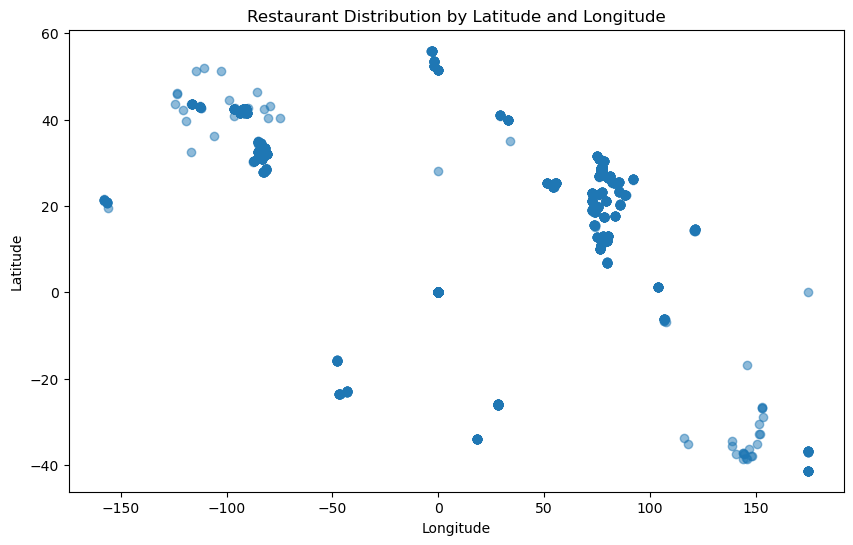

In [6]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['Longitude'],
    df['Latitude'],
    alpha=0.5
)

plt.title("Restaurant Distribution by Latitude and Longitude")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Amritsar          21
Ahmedabad         21
Lucknow           21
Guwahati          21
Name: count, dtype: int64


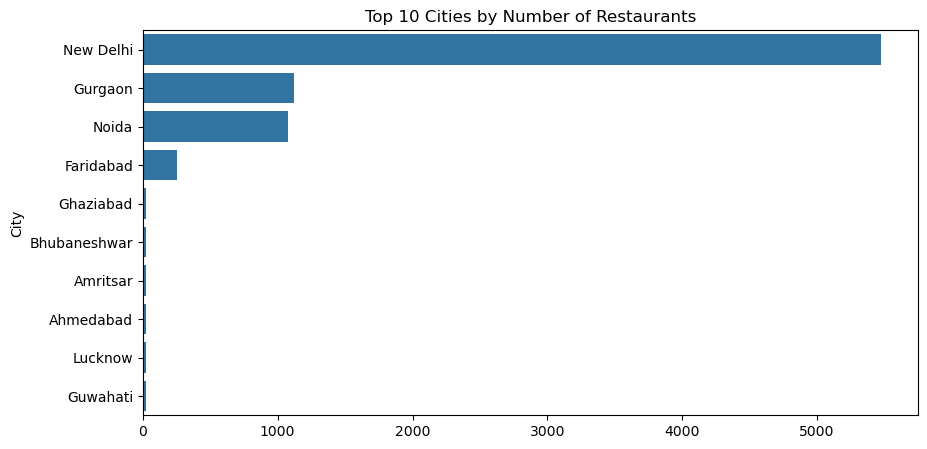

In [7]:
top_cities = df['City'].value_counts().head(10)

print(top_cities)

plt.figure(figsize=(10,5))
sns.barplot(
    x=top_cities.values,
    y=top_cities.index
)

plt.title("Top 10 Cities by Number of Restaurants")
plt.show()

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Tagaytay City       4.500000
Secunderabad        4.500000
Name: Aggregate rating, dtype: float64


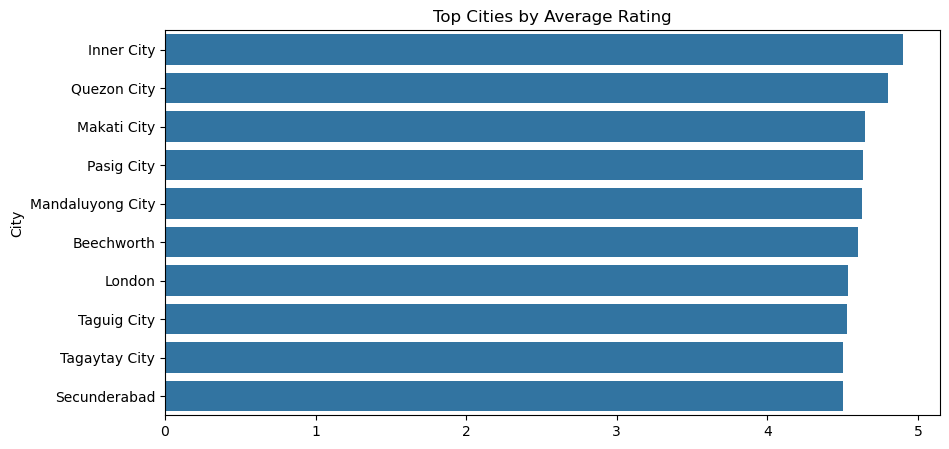

In [8]:
city_rating = (
    df.groupby('City')['Aggregate rating']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(city_rating)

plt.figure(figsize=(10,5))
sns.barplot(
    x=city_rating.values,
    y=city_rating.index
)

plt.title("Top Cities by Average Rating")
plt.show()

In [9]:
city_price = (
    df.groupby('City')['Price range']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(city_price)

City
Princeton           4.000000
Inner City          4.000000
Vineland Station    4.000000
Johannesburg        4.000000
Panchkula           4.000000
Pasay City          4.000000
Paynesville         4.000000
Sandton             3.818182
Mandaluyong City    3.750000
Pretoria            3.700000
Name: Price range, dtype: float64


In [10]:
top_cuisine_city = (
    df.groupby('City')['Cuisines']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else "Unknown")
)

top_cuisine_city.head(20)

City
Abu Dhabi                                               American
Agra                                       North Indian, Mughlai
Ahmedabad       Cafe, American, Continental, Armenian, Fast Food
Albany                                    Japanese, Steak, Sushi
Allahabad                                  North Indian, Chinese
Amritsar                                            North Indian
Ankara                                      Kebab, Turkish Pizza
Armidale                                         Bar Food, Steak
Athens                                  American, Italian, Pizza
Auckland                                                    Cafe
Augusta                                                  Mexican
Aurangabad                                          North Indian
Balingup                                       Modern Australian
Bandung                            Cafe, Coffee and Tea, Western
Bangalore                                   Pizza, Cafe, Italian
Beechworth          

Locality
Connaught Place        122
Rajouri Garden          99
Shahdara                87
Defence Colony          86
Malviya Nagar           85
Pitampura               85
Mayur Vihar Phase 1     84
Rajinder Nagar          81
Safdarjung              80
Satyaniketan            79
Name: count, dtype: int64


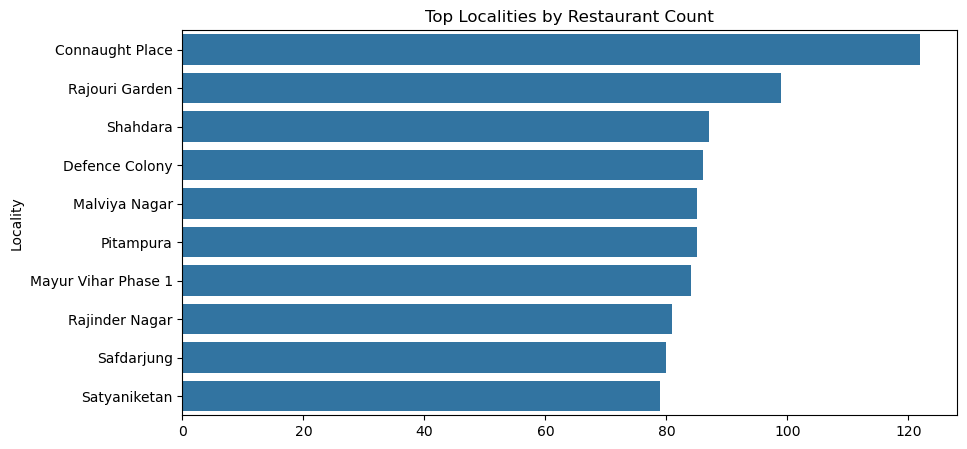

In [11]:
top_localities = df['Locality'].value_counts().head(10)

print(top_localities)

plt.figure(figsize=(10,5))
sns.barplot(
    x=top_localities.values,
    y=top_localities.index
)

plt.title("Top Localities by Restaurant Count")
plt.show()

# Key Insights

1. Restaurants are concentrated in a few major cities, especially Delhi NCR.
2. Connaught Place has the highest restaurant concentration among localities.
3. Cities with more restaurants do not always have the highest average ratings.
4. Higher price range restaurants generally receive better ratings.
5. Restaurant distribution is geographically uneven across locations.
6. Different cities show different dominant cuisine preferences.
7. Location plays an important role in restaurant popularity and customer ratings.

# Conclusion

This location-based analysis explored the geographical distribution of restaurants using latitude and longitude coordinates. City-wise and locality-wise analysis revealed major restaurant hubs, rating trends, cuisine preferences, and pricing patterns. The results demonstrate how location significantly influences restaurant concentration, customer ratings, and dining preferences.